<a href="https://colab.research.google.com/github/ifchandesh/employee_attrition_analysis/blob/main/employee_attrition_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Attrition Analysis & Prediction

This notebook analyzes employee turnover using the IBM HR Analytics dataset, identify Factors Influencing Resignation (Age, Salary, Department, OverTime, Work-Life Balance, Distance From Home, Travel Frequency, and Tenure), builds classification models, and provides an interactive HR dashboard with KPIs.

## 1. Setup & Load Dataset

In [1]:
# Install dependencies if running in Google Colab
!pip install -q gradio scikit-learn seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr
from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Load IBM HR Analytics dataset
data_url = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"
df = pd.read_csv(data_url)

# Drop uninformative / constant columns
drop_cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset Shape: 1470 rows, 31 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


## 2. Exploratory Data Analysis
We examine how **Age, Salary, Department, OverTime, Job Satisfaction,
Work-Life Balance, Commute Distance, Business Travel, and Tenure**
are associated with employee attrition.

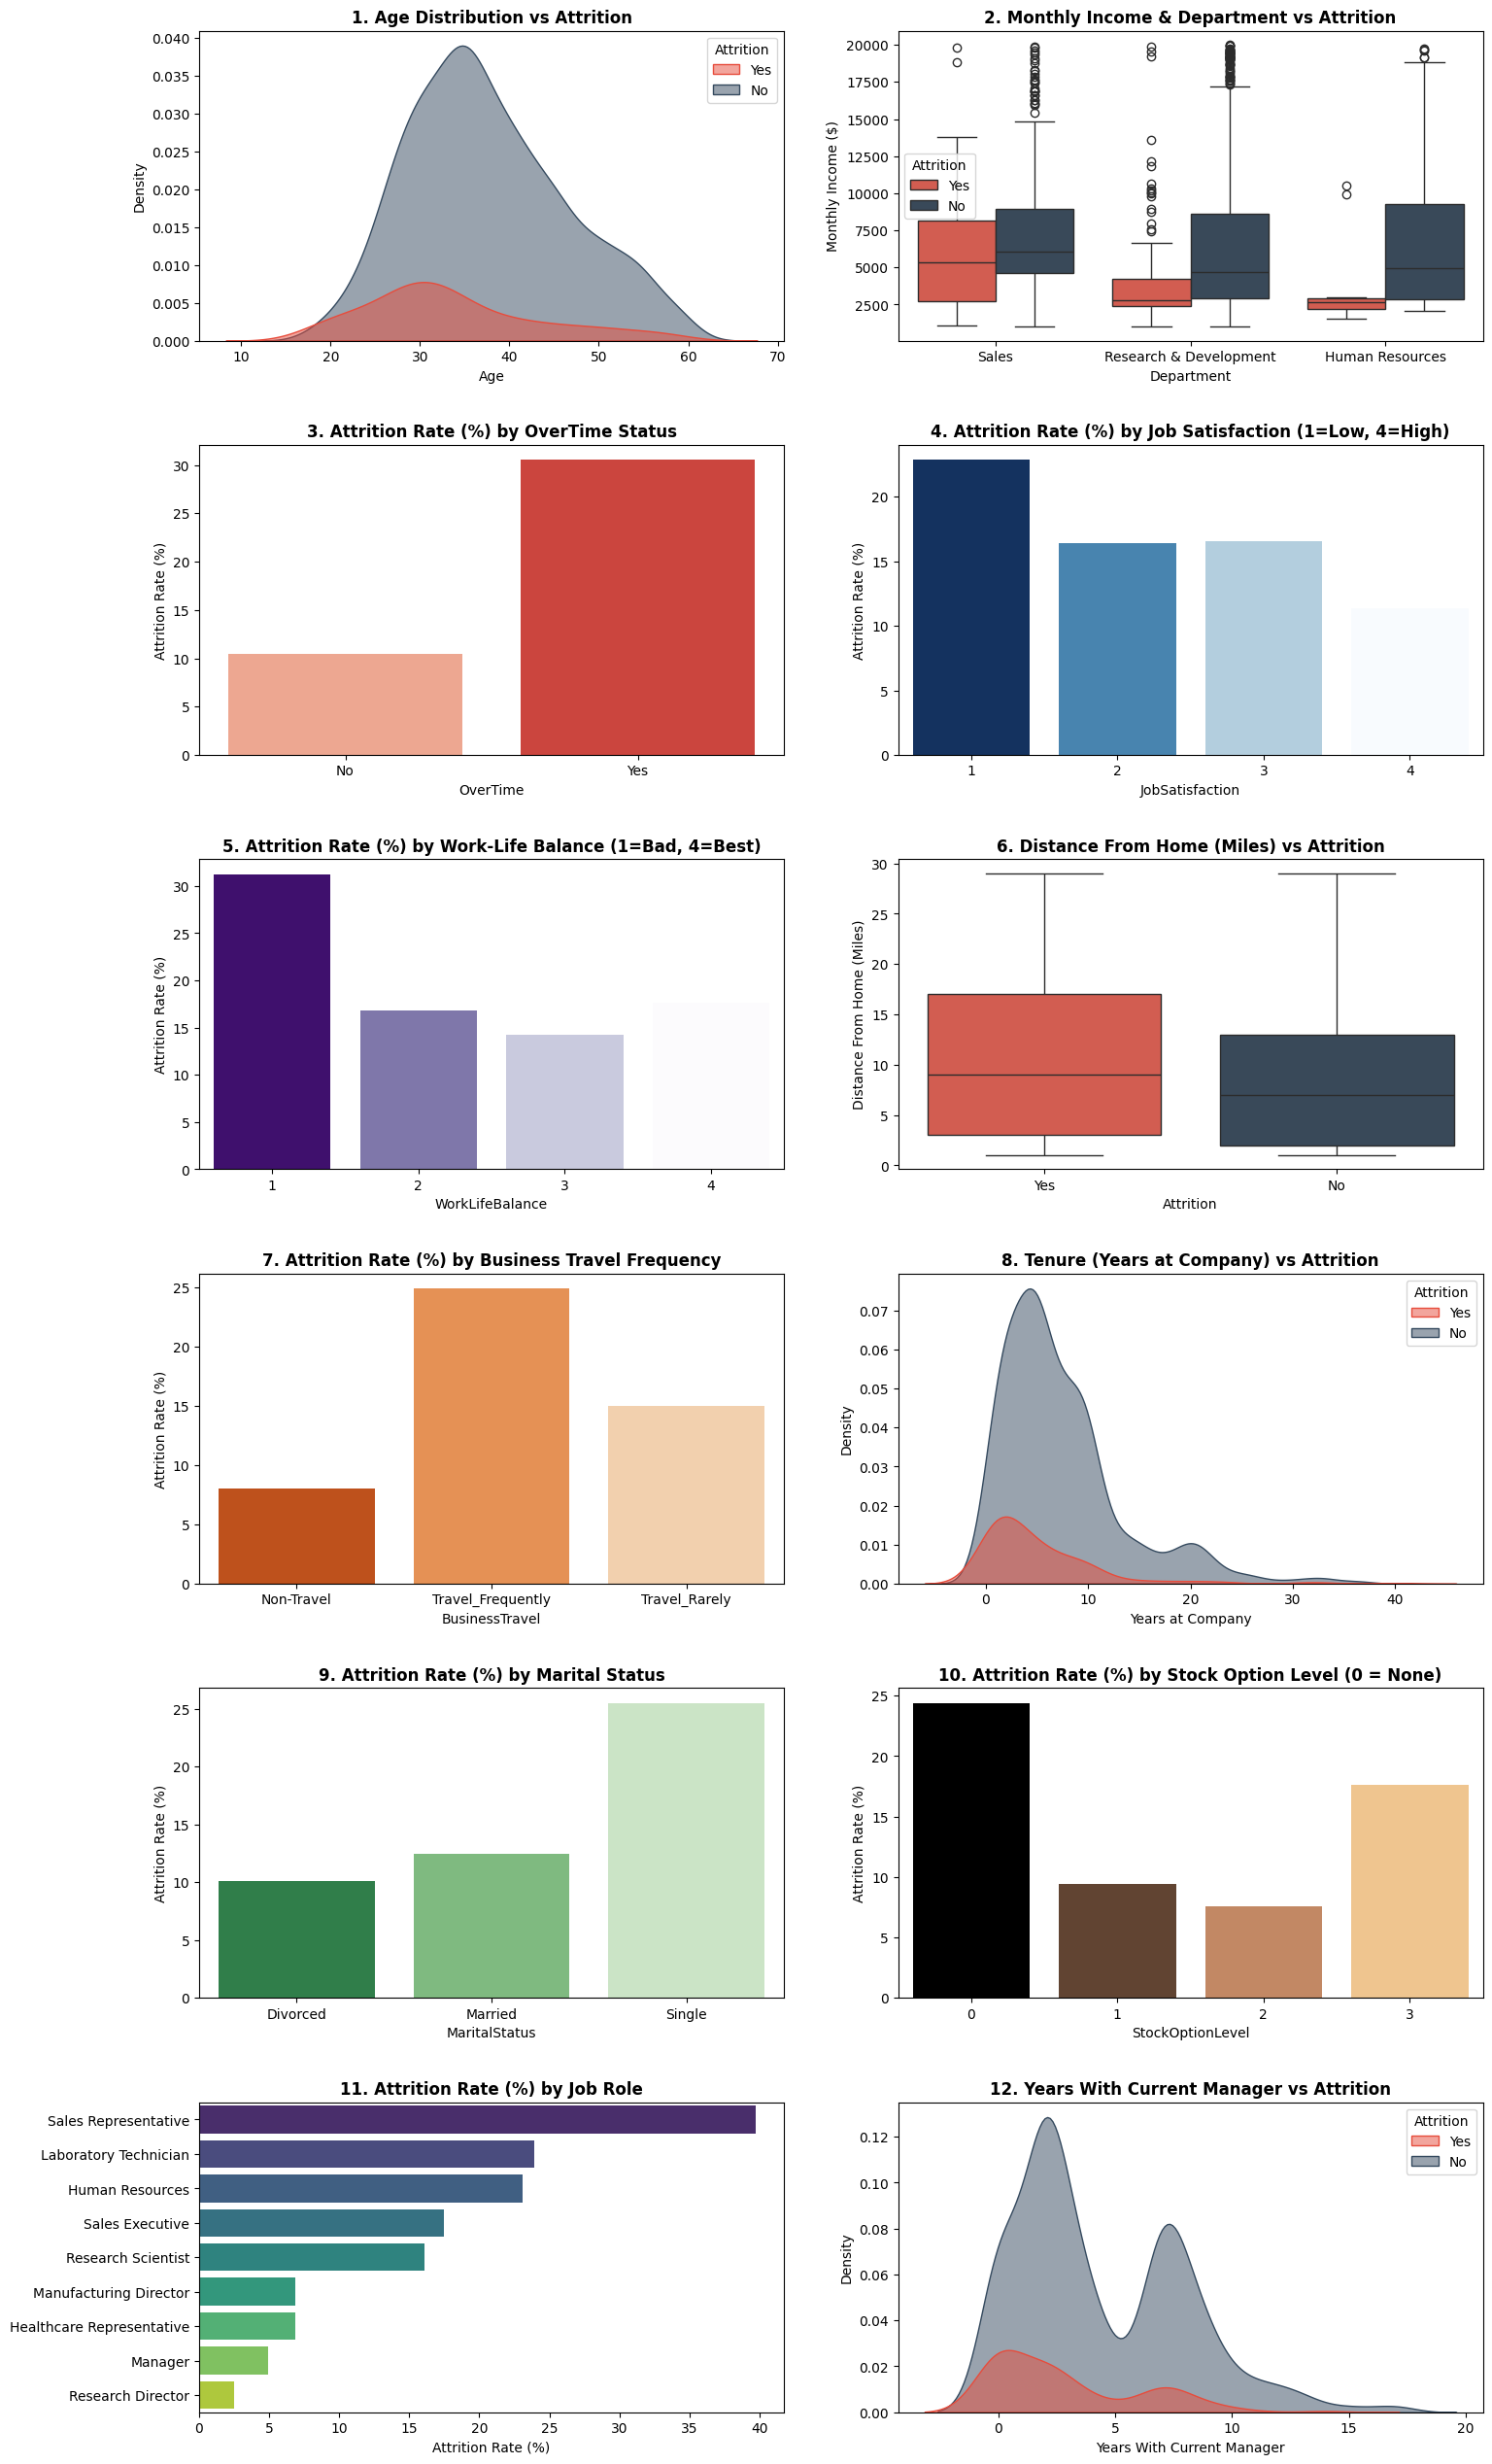

In [3]:
# Comprehensive EDA: Visualizing 12 key factors driving attrition
fig, axes = plt.subplots(6, 2, figsize=(16, 26))
palette = {'Yes': '#e74c3c', 'No': '#34495e'}

# 1. Age Distribution
sns.kdeplot(data=df, x='Age', hue='Attrition', fill=True, palette=palette, ax=axes[0, 0], alpha=0.5)
axes[0, 0].set_title("1. Age Distribution vs Attrition", fontweight='bold')
axes[0, 0].set_xlabel("Age")

# 2. Monthly Income by Department
sns.boxplot(data=df, x='Department', y='MonthlyIncome', hue='Attrition', palette=palette, ax=axes[0, 1])
axes[0, 1].set_title("2. Monthly Income & Department vs Attrition", fontweight='bold')
axes[0, 1].set_xlabel("Department")
axes[0, 1].set_ylabel("Monthly Income ($)")

# 3. OverTime Impact
ot_pct = df.groupby('OverTime')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
sns.barplot(data=ot_pct, x='OverTime', y='Attrition', hue='OverTime', palette='Reds', legend=False, ax=axes[1, 0])
axes[1, 0].set_title("3. Attrition Rate (%) by OverTime Status", fontweight='bold')
axes[1, 0].set_ylabel("Attrition Rate (%)")

# 4. Job Satisfaction Impact
sat_pct = df.groupby('JobSatisfaction')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
sns.barplot(data=sat_pct, x='JobSatisfaction', y='Attrition', hue='JobSatisfaction', palette='Blues_r', legend=False, ax=axes[1, 1])
axes[1, 1].set_title("4. Attrition Rate (%) by Job Satisfaction (1=Low, 4=High)", fontweight='bold')
axes[1, 1].set_ylabel("Attrition Rate (%)")

# 5. Work-Life Balance Impact
wlb_pct = df.groupby('WorkLifeBalance')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
sns.barplot(data=wlb_pct, x='WorkLifeBalance', y='Attrition', hue='WorkLifeBalance', palette='Purples_r', legend=False, ax=axes[2, 0])
axes[2, 0].set_title("5. Attrition Rate (%) by Work-Life Balance (1=Bad, 4=Best)", fontweight='bold')
axes[2, 0].set_ylabel("Attrition Rate (%)")

# 6. Distance From Home Impact
sns.boxplot(data=df, x='Attrition', y='DistanceFromHome', hue='Attrition', palette=palette, legend=False, ax=axes[2, 1])
axes[2, 1].set_title("6. Distance From Home (Miles) vs Attrition", fontweight='bold')
axes[2, 1].set_ylabel("Distance From Home (Miles)")

# 7. Business Travel Frequency
travel_pct = df.groupby('BusinessTravel')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
sns.barplot(data=travel_pct, x='BusinessTravel', y='Attrition', hue='BusinessTravel', palette='Oranges_r', legend=False, ax=axes[3, 0])
axes[3, 0].set_title("7. Attrition Rate (%) by Business Travel Frequency", fontweight='bold')
axes[3, 0].set_ylabel("Attrition Rate (%)")

# 8. Tenure Distribution (Years at Company)
sns.kdeplot(data=df, x='YearsAtCompany', hue='Attrition', fill=True, palette=palette, ax=axes[3, 1], alpha=0.5)
axes[3, 1].set_title("8. Tenure (Years at Company) vs Attrition", fontweight='bold')
axes[3, 1].set_xlabel("Years at Company")

# 9. Marital Status
marital_pct = df.groupby('MaritalStatus')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
sns.barplot(data=marital_pct, x='MaritalStatus', y='Attrition', hue='MaritalStatus', palette='Greens_r', legend=False, ax=axes[4, 0])
axes[4, 0].set_title("9. Attrition Rate (%) by Marital Status", fontweight='bold')
axes[4, 0].set_ylabel("Attrition Rate (%)")

# 10. Stock Option Level
stock_pct = df.groupby('StockOptionLevel')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
sns.barplot(data=stock_pct, x='StockOptionLevel', y='Attrition', hue='StockOptionLevel', palette='copper', legend=False, ax=axes[4, 1])
axes[4, 1].set_title("10. Attrition Rate (%) by Stock Option Level (0 = None)", fontweight='bold')
axes[4, 1].set_ylabel("Attrition Rate (%)")

# 11. Job Role (Horizontal Barplot for readability)
role_pct = df.groupby('JobRole')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index().sort_values('Attrition', ascending=False)
sns.barplot(data=role_pct, y='JobRole', x='Attrition', hue='JobRole', palette='viridis', legend=False, ax=axes[5, 0])
axes[5, 0].set_title("11. Attrition Rate (%) by Job Role", fontweight='bold')
axes[5, 0].set_xlabel("Attrition Rate (%)")
axes[5, 0].set_ylabel("")

# 12. Years With Current Manager
sns.kdeplot(data=df, x='YearsWithCurrManager', hue='Attrition', fill=True, palette=palette, ax=axes[5, 1], alpha=0.5)
axes[5, 1].set_title("12. Years With Current Manager vs Attrition", fontweight='bold')
axes[5, 1].set_xlabel("Years With Current Manager")

plt.tight_layout(pad=3.0)
plt.show()

## 3. Classification Algorithms & Model Evaluation
We prepare features, train **Logistic Regression, Decision Tree, and Random Forest** models with 5-fold cross validation, evaluate metrics, and visualize confusion matrices.

In [4]:
# Prepare features and target
X = df.drop(columns=['Attrition'])
y = (df['Attrition'] == 'Yes').astype(int)

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train and evaluate models
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=150,
        max_depth=8,
        class_weight='balanced',
        random_state=42
    )
}

results = []
trained_pipes = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    cv_auc = cross_val_score(
        pipe, X_train, y_train,
        cv=cv,
        scoring='roc_auc'
    ).mean()

    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred), 3),
        'Recall (Sensitivity)': round(recall_score(y_test, y_pred), 3),
        'F1-Score': round(f1_score(y_test, y_pred), 3),
        'MCC': round(matthews_corrcoef(y_test, y_pred), 3),
        'Test ROC-AUC': round(roc_auc_score(y_test, y_proba), 3),
        '5-Fold CV ROC-AUC': round(cv_auc, 3)
    })

    trained_pipes[name] = pipe

results_df = pd.DataFrame(results)

# Display model comparison
display(results_df)

,Model,Accuracy,Precision,Recall (Sensitivity),F1-Score,MCC,Test ROC-AUC,5-Fold CV ROC-AUC
0,Logistic Regression,0.752,0.349,0.638,0.451,0.332,0.803,0.827
1,Decision Tree,0.786,0.379,0.532,0.442,0.321,0.653,0.626
2,Random Forest,0.833,0.455,0.213,0.290,0.229,0.792,0.791


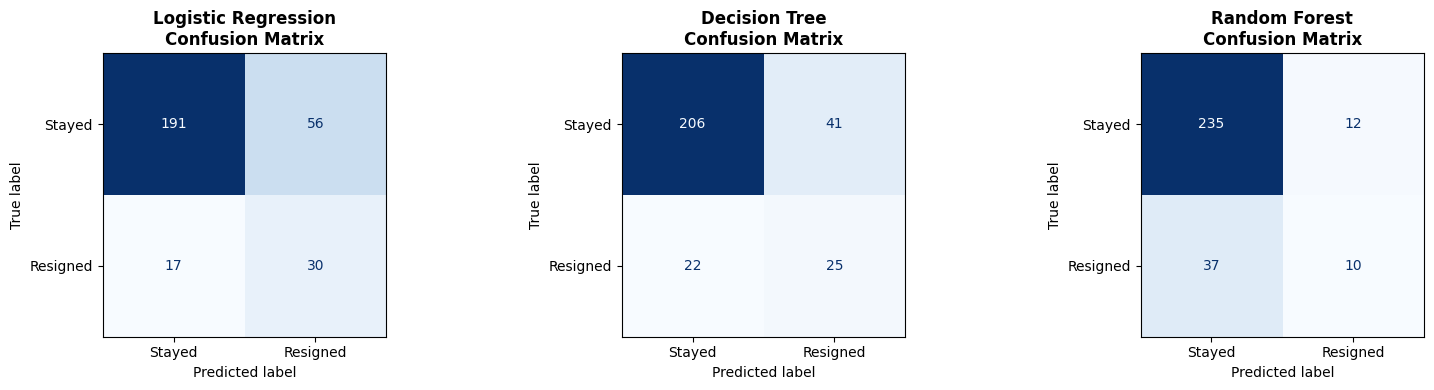

In [5]:
# Visualizing Confusion Matrices across all models

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, (name, pipe) in enumerate(trained_pipes.items()):

    y_pred = pipe.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Stayed', 'Resigned']
    )

    disp.plot(
        ax=axes[idx],
        cmap='Blues',
        colorbar=False
    )

    axes[idx].set_title(
        f"{name}\nConfusion Matrix",
        fontweight='bold'
    )

    axes[idx].grid(False)

plt.tight_layout()
plt.show()

In [17]:
selected_model_name = 'Logistic Regression'
best_pipe = trained_pipes[selected_model_name]

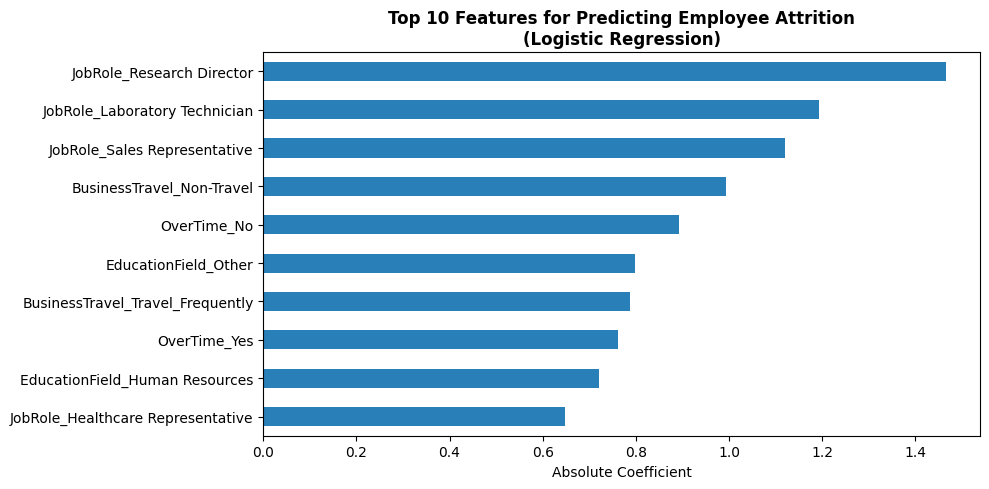

TOP 10 FEATURES - Logistic Regression
JobRole_Research Director                1.4657
JobRole_Laboratory Technician            1.1943
JobRole_Sales Representative             1.1206
BusinessTravel_Non-Travel                0.9939
OverTime_No                              0.8928
EducationField_Other                     0.7981
BusinessTravel_Travel_Frequently         0.7876
OverTime_Yes                             0.7615
EducationField_Human Resources           0.7211
JobRole_Healthcare Representative        0.6472


In [18]:
# Top 10 Features for Predicting Employee Attrition

selected_model = best_pipe.named_steps['classifier']

# Get feature names after preprocessing
encoded_cat_names = (
    best_pipe
    .named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(cat_cols)
)

all_features = num_cols + list(encoded_cat_names)

# Get feature importance
if hasattr(selected_model, 'coef_'):
    importance = abs(selected_model.coef_[0])
    label = "Absolute Coefficient"
else:
    importance = selected_model.feature_importances_
    label = "Feature Importance"

# Top 10
feat_imp = (
    pd.Series(importance, index=all_features)
    .sort_values(ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(10, 5))

feat_imp.sort_values().plot(
    kind='barh',
    color='#2980b9'
)

plt.title(
    f"Top 10 Features for Predicting Employee Attrition\n"
    f"({selected_model_name})",
    fontweight='bold'
)

plt.xlabel(label)
plt.tight_layout()
plt.show()

# Print
print("=" * 60)
print(f"TOP 10 FEATURES - {selected_model_name}")
print("=" * 60)

for feature, importance in feat_imp.items():
    print(f"{feature:<40} {importance:.4f}")

## 4. HR Analytics Results Dashboard
An interactive dashboard summarizing key HR metrics, exploratory
data analysis findings, model performance, and important predictive
features identified from the employee attrition analysis.

In [19]:
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# ============================================================
# EDA CHARTS
# ============================================================

palette = {
    "Yes": "#e74c3c",
    "No": "#34495e"
}


# 1. Age Distribution
def age_plot():

    fig, ax = plt.subplots(figsize=(7, 4))

    sns.kdeplot(
        data=df,
        x="Age",
        hue="Attrition",
        fill=True,
        palette=palette,
        alpha=0.5,
        ax=ax
    )

    ax.set_title(
        "Age Distribution vs Attrition",
        fontweight="bold"
    )

    ax.set_xlabel("Age")
    ax.set_ylabel("Density")

    plt.tight_layout()

    return fig


# 3. OverTime
def overtime_plot():

    data = (
        df.groupby("OverTime")["Attrition"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(7, 4))

    sns.barplot(
        data=data,
        x="OverTime",
        y="Attrition",
        hue="OverTime",
        palette="Reds",
        legend=False,
        ax=ax
    )

    ax.set_title(
        "Attrition Rate (%) by OverTime Status",
        fontweight="bold"
    )

    ax.set_xlabel("OverTime")
    ax.set_ylabel("Attrition Rate (%)")

    plt.tight_layout()

    return fig


# 4. Job Satisfaction
def satisfaction_plot():

    data = (
        df.groupby("JobSatisfaction")["Attrition"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(7, 4))

    sns.barplot(
        data=data,
        x="JobSatisfaction",
        y="Attrition",
        hue="JobSatisfaction",
        palette="Blues_r",
        legend=False,
        ax=ax
    )

    ax.set_title(
        "Attrition Rate (%) by Job Satisfaction",
        fontweight="bold"
    )

    ax.set_xlabel("Job Satisfaction (1 = Low, 4 = High)")
    ax.set_ylabel("Attrition Rate (%)")

    plt.tight_layout()

    return fig


# 5. Work-Life Balance
def worklife_plot():

    data = (
        df.groupby("WorkLifeBalance")["Attrition"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(7, 4))

    sns.barplot(
        data=data,
        x="WorkLifeBalance",
        y="Attrition",
        hue="WorkLifeBalance",
        palette="Purples_r",
        legend=False,
        ax=ax
    )

    ax.set_title(
        "Attrition Rate (%) by Work-Life Balance",
        fontweight="bold"
    )

    ax.set_xlabel("Work-Life Balance (1 = Bad, 4 = Best)")
    ax.set_ylabel("Attrition Rate (%)")

    plt.tight_layout()

    return fig


# 7. Business Travel
def travel_plot():

    data = (
        df.groupby("BusinessTravel")["Attrition"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(7, 4))

    sns.barplot(
        data=data,
        x="BusinessTravel",
        y="Attrition",
        hue="BusinessTravel",
        palette="Oranges_r",
        legend=False,
        ax=ax
    )

    ax.set_title(
        "Attrition Rate (%) by Business Travel",
        fontweight="bold"
    )

    ax.set_xlabel("Business Travel")
    ax.set_ylabel("Attrition Rate (%)")

    plt.xticks(rotation=10)

    plt.tight_layout()

    return fig


# 8. Years at Company
def tenure_plot():

    fig, ax = plt.subplots(figsize=(7, 4))

    sns.kdeplot(
        data=df,
        x="YearsAtCompany",
        hue="Attrition",
        fill=True,
        palette=palette,
        alpha=0.5,
        ax=ax
    )

    ax.set_title(
        "Tenure (Years at Company) vs Attrition",
        fontweight="bold"
    )

    ax.set_xlabel("Years at Company")
    ax.set_ylabel("Density")

    plt.tight_layout()

    return fig


# 9. Marital Status
def marital_plot():

    data = (
        df.groupby("MaritalStatus")["Attrition"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(7, 4))

    sns.barplot(
        data=data,
        x="MaritalStatus",
        y="Attrition",
        hue="MaritalStatus",
        palette="Greens_r",
        legend=False,
        ax=ax
    )

    ax.set_title(
        "Attrition Rate (%) by Marital Status",
        fontweight="bold"
    )

    ax.set_xlabel("Marital Status")
    ax.set_ylabel("Attrition Rate (%)")

    plt.tight_layout()

    return fig


# ============================================================
# MODEL RESULTS
# ============================================================

model_table = results_df.reset_index()

feature_table = (
    feat_imp.head(10)
    .rename("Importance")
    .reset_index()
)

feature_table.columns = ["Feature", "Importance"]


# ============================================================
# DASHBOARD
# ============================================================

with gr.Blocks() as demo:

    # --------------------------------------------------------
    # Header
    # --------------------------------------------------------

    gr.Markdown(
        """
        # Employee Attrition Analysis

        **Exploratory Data Analysis and Machine Learning Results**
        """
    )

    # --------------------------------------------------------
    # Dataset Overview
    # --------------------------------------------------------

    gr.Markdown("## Dataset Overview")

    with gr.Row():

        gr.Markdown(
            f"""
            ### Total Employees
            ## {len(df):,}
            """
        )

        gr.Markdown(
            f"""
            ### Attrition Cases
            ## {(df["Attrition"] == "Yes").sum():,}
            """
        )

        gr.Markdown(
            f"""
            ### Attrition Rate
            ## {(df["Attrition"] == "Yes").mean() * 100:.2f}%
            """
        )

    # --------------------------------------------------------
    # EDA
    # --------------------------------------------------------

    gr.Markdown("## Exploratory Data Analysis")

    gr.Markdown(
        """
        Key relationships identified during exploratory analysis.
        """
    )

    # Row 1
    with gr.Row():
        gr.Plot(age_plot())
        gr.Plot(overtime_plot())

    # Row 2
    with gr.Row():
        gr.Plot(satisfaction_plot())
        gr.Plot(worklife_plot())

    # Row 3
    with gr.Row():
        gr.Plot(travel_plot())
        gr.Plot(tenure_plot())

    # Row 4
    with gr.Row():
        gr.Plot(marital_plot())

    # --------------------------------------------------------
    # Model Performance
    # --------------------------------------------------------

    gr.Markdown("## Model Performance")

    gr.Dataframe(
        model_table,
        interactive=False
    )

    # --------------------------------------------------------
    # Feature Importance
    # --------------------------------------------------------

    gr.Markdown("## Top Predictive Features")

    feature_fig, feature_ax = plt.subplots(figsize=(8, 5))

    feat_imp.head(10).sort_values().plot(
        kind="barh",
        ax=feature_ax
    )

    feature_ax.set_title(
        "Top 10 Predictive Features",
        fontweight="bold"
    )

    feature_ax.set_xlabel("Feature Importance")
    feature_ax.set_ylabel("")

    plt.tight_layout()

    with gr.Row():

        gr.Plot(feature_fig)

        gr.Dataframe(
            feature_table,
            interactive=False
        )

    # --------------------------------------------------------
    # Key Findings
    # --------------------------------------------------------

    gr.Markdown(
        """
        ## Key Findings

        **Overtime**

        Employees working overtime show substantially higher
        attrition rates than employees who do not work overtime.

        **Job Satisfaction**

        Lower job-satisfaction levels are associated with
        higher observed attrition rates.

        **Work-Life Balance**

        Employees reporting poorer work-life balance show
        higher observed attrition rates.

        **Business Travel**

        Attrition rates vary considerably across business-travel
        frequencies, with frequent travelers showing higher
        attrition.

        **Tenure**

        Employees with shorter tenure generally show higher
        attrition patterns.

        **Marital Status**

        Single employees show a higher observed attrition rate
        than married or divorced employees.

        **Age**

        The age distributions indicate that employees who leave
        tend to be concentrated at younger ages compared with
        employees who stay.

        > **Note:** These findings represent associations observed
        > in the dataset and should not be interpreted as causal
        > relationships.
        """
    )


# ============================================================
# LAUNCH
# ============================================================

demo.launch(
    theme=gr.themes.Soft()
)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0cd192f1888472feab.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
